# TD3 for DBS — clean re-run

Modules at **2.6.0**. Earlier runs used an RMS value corrupted by integer overflow
(`dbs ** 2` wrapping negative), so the energy term was wrong throughout. All array
arithmetic is now done in float64.

Run in order. Do not skip cell 4.

| # | Step | MATLAB | Time |
|---|---|---|---|
| 1 | Version check | no | instant |
| 2 | Offline checks | no | ~1 min |
| 3 | Start MATLAB | yes | ~1 min |
| 4 | Live env checks | yes | ~5 min |
| 5 | Choose rms_max | no | instant |
| 6 | Apply rms_max | yes | ~5 min |
| 7 | Fixed-policy baselines | yes | ~10 min |
| 8 | Short run (30 eps) | yes | ~15 min |
| 9 | Full run | yes | ~3 hrs |
| 10 | Evaluate | yes | ~15 min |
| 11 | Switch to 32 and repeat | yes | ~3 hrs |
| 12 | Compare | no | instant |

## 1. Version check

In [2]:
import importlib
import numpy as np
import dbs_core, dbs_plots, dbs_checks
for m in (dbs_core, dbs_plots, dbs_checks):
    importlib.reload(m)

from dataclasses import replace
from dbs_core import Config, MatlabEnv, MockEnv, TD3Agent, train, evaluate

assert dbs_checks.versions(), "stale file — re-download all three .py files, restart kernel"

module versions:
  dbs_core     2.6.0
  dbs_plots    2.6.0
  dbs_checks   2.6.0

  all modules at 2.6.0 — files are in sync


## 2. Offline checks

Expect **13 passed, 0 failed** for each. Says nothing about MATLAB — that is cell 4.

In [3]:
assert dbs_checks.offline(64)
print()
assert dbs_checks.offline(32)

  [PASS] actor output shape
  [PASS] actor bounded in [-1,1]
  [PASS] critic returns scalars
  [PASS] twin critics differ
         actor=4610 critic=9346 params
  [PASS] action min -> (0,0)
  [PASS] action max -> bounds
  [PASS] buffer caps at max_size
  [PASS] buffer wraps
  [PASS] hjorth returns 4 finite values — window (10, 100)
  [PASS] time-limit steps NOT marked done — 0 of 10
  [PASS] checkpoint roundtrip
  [PASS] learns on mock env — -0.1244 -> -0.0904
  [PASS] no collapse on mock — final freq 148.8 Hz

offline checks (hidden_dim=64): 13 passed, 0 failed

  [PASS] actor output shape
  [PASS] actor bounded in [-1,1]
  [PASS] critic returns scalars
  [PASS] twin critics differ
         actor=1282 critic=2626 params
  [PASS] action min -> (0,0)
  [PASS] action max -> bounds
  [PASS] buffer caps at max_size
  [PASS] buffer wraps
  [PASS] hjorth returns 4 finite values — window (10, 100)
  [PASS] time-limit steps NOT marked done — 0 of 10
  [PASS] checkpoint roundtrip
  [PASS] learn

## 3. Start MATLAB

Once per session. If you edit a `.py` file, restart the kernel and start again from
cell 1 — do not reload, it leaves objects bound to stale classes.

`rms_max` is a placeholder here; cell 5 determines the real value.

In [4]:
cfg = Config(
    hidden_dim=64,
    pd_value=0.4,
    tmax=1500,
    steps_per_episode=15,
    n_episodes=500,
    checkpoint_every=50,
    rms_max=300.0,
    freq_max=185.0,
    run_dir="runs",
    tag="v3",
)

menv = MatlabEnv(cfg, mat_path="bgn_vars.mat")
print("MATLAB engine started")
print("dbs dtype check:")
menv.reset()
d = menv._load()
for k in ("dbs", "vgi", "sgis"):
    print(f"  {k:<6} dtype {str(d[k].dtype):<10} max {np.abs(d[k]).max():.1f}")

MATLAB engine started
dbs dtype check:
  dbs    dtype float64    max 0.0
  vgi    dtype float64    max 78.8
  sgis   dtype float64    max 0.6


## 4. Live environment checks

Probes the real model at seven actions, 3 settle steps then 4 measured. All 11 checks
must pass. The RMS column is the one that changed — expect values well above the
20-40 range seen before the float64 fix.

In [5]:
ok, samples, rows = dbs_checks.live(menv, cfg)
print()
print("observed rms range:", tuple(round(v, 1) for v in dbs_checks.rms_range(samples)))

  [PASS] reset returns correct state_dim
  [PASS] state values finite
  [PASS] hjorth window has enough samples — window (10, 250), expected ~250 (sim_time_per_step=100 ms / dt=0.01)

  1 episode(s) x 4 steps per action (first 3 steps discarded as DBS turn-on transient)

  action              sgis      rms     r1     r2    reward
  --------------------------------------------------------
  no DBS             634.3     0.00  0.279  0.000   -0.1393  (sgis sd 40.1)
  100Hz/1000         443.3   173.21  0.119  0.577   -0.1752  (sgis sd 131.9)
  130Hz/1000         398.6   198.24  0.082  0.661   -0.1733  (sgis sd 21.5)
  155Hz/1000         550.7   216.22  0.209  0.721   -0.2486  (sgis sd 75.2)
  180Hz/1000         300.4   232.38  0.000  0.775   -0.1551  (sgis sd 37.9)
  155Hz/2500         649.8   540.54  0.292  1.000   -0.3458  (sgis sd 107.6)
  180Hz/5000         374.7  1161.90  0.062  1.000   -0.2311  (sgis sd 55.4)

  [PASS] sgis in plausible range — median 443.3, expected order 100-2000
 

## 5. Choose rms_max

Candidates are scaled from the observed RMS. The suggestion is the largest value whose
best action still uses the **lowest** amplitude — a larger margin is not better if it is
bought by rewarding maximum current.

In [6]:
probes = {k: {"sgis": float(np.mean([r["sgis"] for r in v])),
              "rms": float(np.mean([r["rms"] for r in v])),
              "freq": k[0], "amp": k[1]}
          for k, v in samples.items()}
suggestion = dbs_checks.tune_rms_max(cfg, probes)

observed max rms 1161.9 -> candidates scaled from it

  rms_max | best stim action |    margin | winner amp
--------------------------------------------------------
    697.1 | 180Hz/1000       |   +0.0725 |       1000
    929.5 | 180Hz/1000       |   +0.0891 |       1000
   1161.9 | 180Hz/1000       |   +0.0991 |       1000
   1394.3 | 180Hz/1000       |   +0.1058 |       1000
   1742.8 | 180Hz/1000       |   +0.1125 |       1000
   2323.8 | 180Hz/1000       |   +0.1191 |       1000
   3485.7 | 180Hz/1000       |   +0.1258 |       1000
   5809.5 | 180Hz/1000       |   +0.1311 |       1000
  11619.0 | 180Hz/1000       |   +0.1351 |       1000

  suggested rms_max = 11619.0 (margin +0.1351, winner uses 1000 uA/cm2)
  chosen as the largest value whose best action still uses the lowest amplitude available


## 6. Apply it

Edit the number to whatever cell 5 suggested, then re-check.

In [7]:
cfg = replace(cfg, rms_max=1200.0)
menv.cfg = cfg
print("rms_max =", cfg.rms_max)
ok, samples, rows = dbs_checks.live(menv, cfg, verbose=True)
assert ok

rms_max = 1200.0
  [PASS] reset returns correct state_dim
  [PASS] state values finite
  [PASS] hjorth window has enough samples — window (10, 250), expected ~250 (sim_time_per_step=100 ms / dt=0.01)

  1 episode(s) x 4 steps per action (first 3 steps discarded as DBS turn-on transient)

  action              sgis      rms     r1     r2    reward
  --------------------------------------------------------
  no DBS             759.0     0.00  0.383  0.000   -0.1913  (sgis sd 32.0)
  100Hz/1000         433.0   173.21  0.111  0.144   -0.0843  (sgis sd 120.5)
  130Hz/1000         403.5   198.24  0.086  0.165   -0.0762  (sgis sd 8.6)
  155Hz/1000         603.1   216.22  0.253  0.180   -0.1623  (sgis sd 68.6)
  180Hz/1000         370.6   232.38  0.059  0.194   -0.0682  (sgis sd 75.9)
  155Hz/2500         568.5   540.54  0.224  0.450   -0.2020  (sgis sd 23.4)
  180Hz/5000         425.4  1161.90  0.104  0.968   -0.2459  (sgis sd 21.4)

  [PASS] sgis in plausible range — median 433.0, expected o

## 7. Fixed-policy baselines

Evaluates constant-parameter policies through the same episode structure the agent sees.
This is the o-DBS baseline — the number the learned policy has to beat, and a row in the
results table either way.

In [ ]:
# fixed = dbs_checks.baseline(menv, cfg, n_episodes=5)


td3_h64_pd0.3_v3  |  started 20:05:39
  [PASS] reset returns correct state_dim
  [PASS] state values finite
  [PASS] hjorth window has enough samples — window (10, 250), expected ~250 (sim_time_per_step=100 ms / dt=0.01)

  [PASS] sgis in plausible range — median 494.6, expected order 100-2000
  [PASS] feature 'sd' inside bounds — 28/28 in [25.125, 34.542], observed [26.275, 32.822]
  [PASS] feature 'activity' inside bounds — 28/28 in [634.501, 1189.581], observed [692.173, 1077.742]
  [PASS] feature 'mobility' inside bounds — 28/28 in [0.807, 0.910], observed [0.823, 0.901]
  [PASS] feature 'complexity' inside bounds — 28/28 in [1.505, 1.683], observed [1.512, 1.658]
  [PASS] biomarker term not saturated — mean r1 = 0.169
  [PASS] reward varies across actions — spread 0.1847
  [PASS] stimulating beats doing nothing — margin +0.1507 — below 0.02 risks no-stim collapse

live environment checks: 11 passed, 0 failed
[td3_h64_pd0.3_v3] actor 4610 | critic 9346 | pd=0.3 | rms_max=1200.0 | 

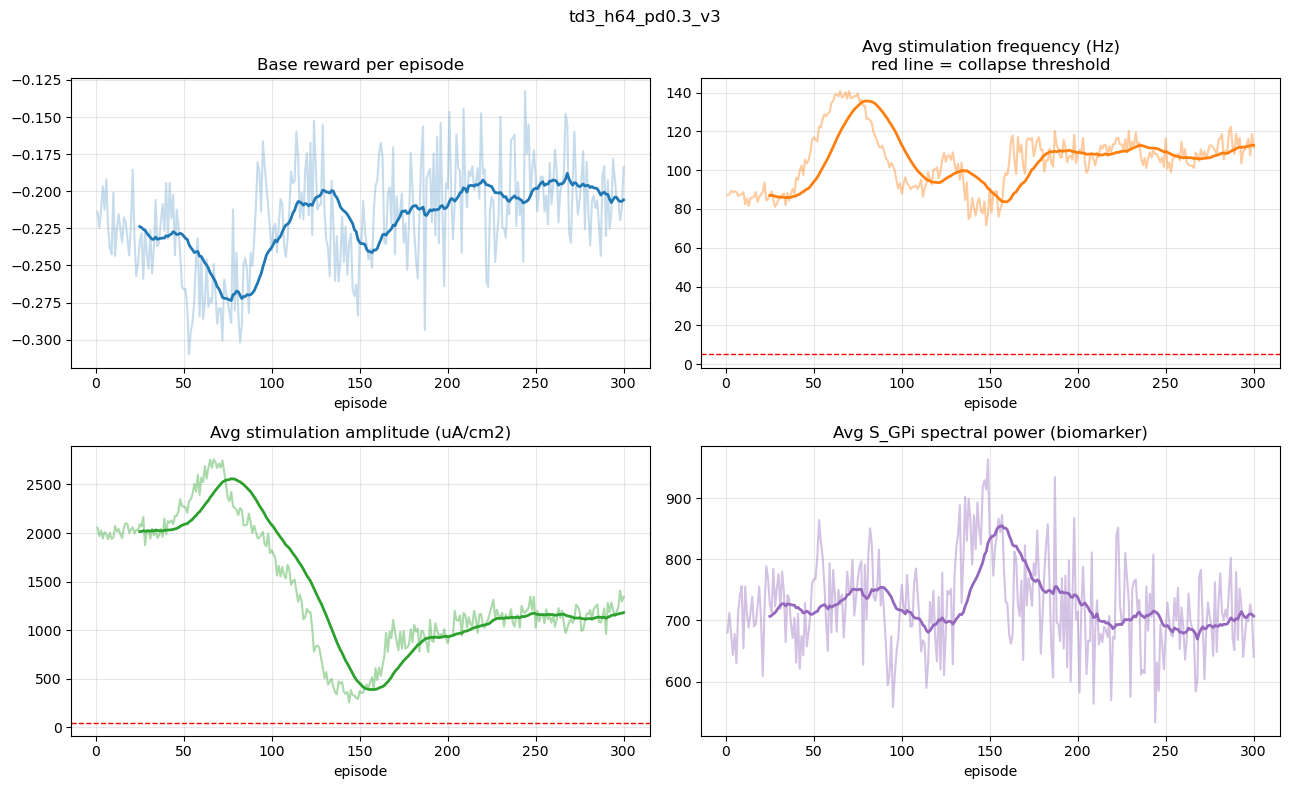

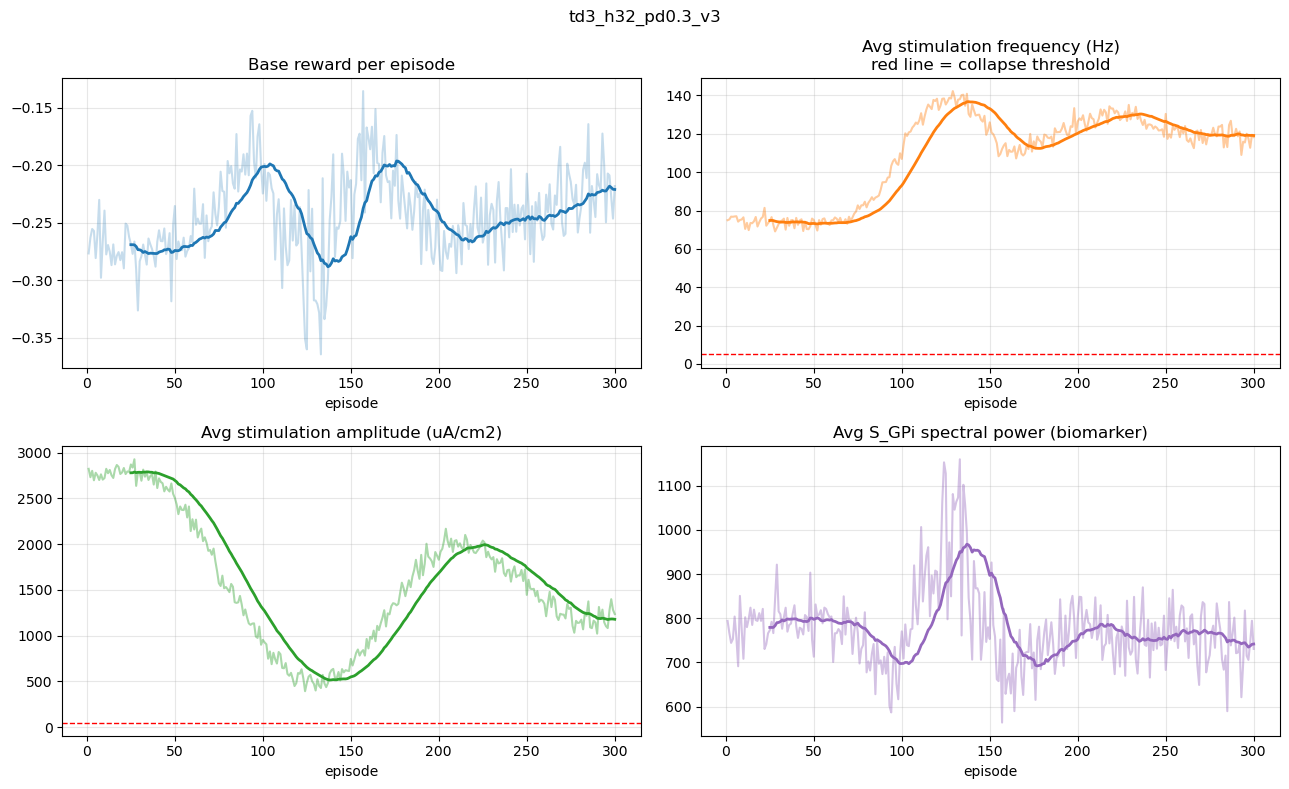

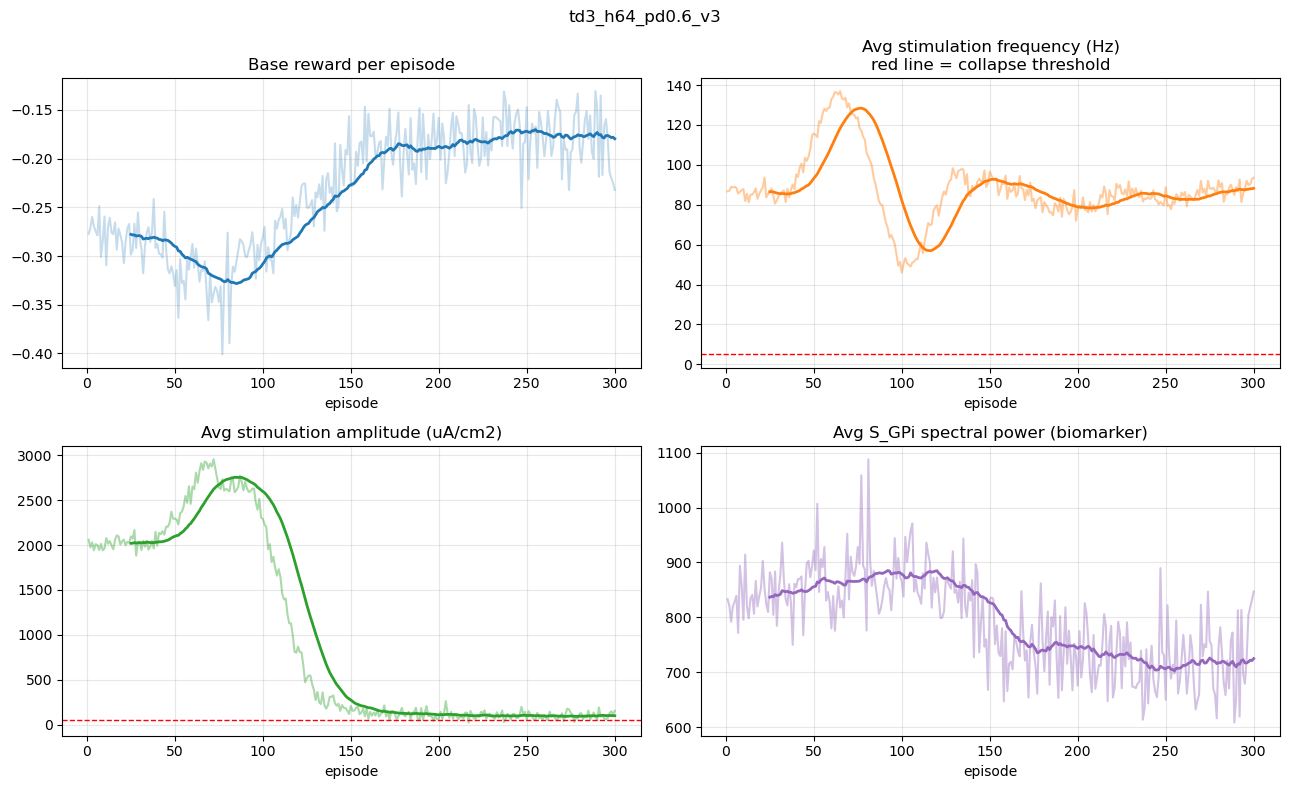

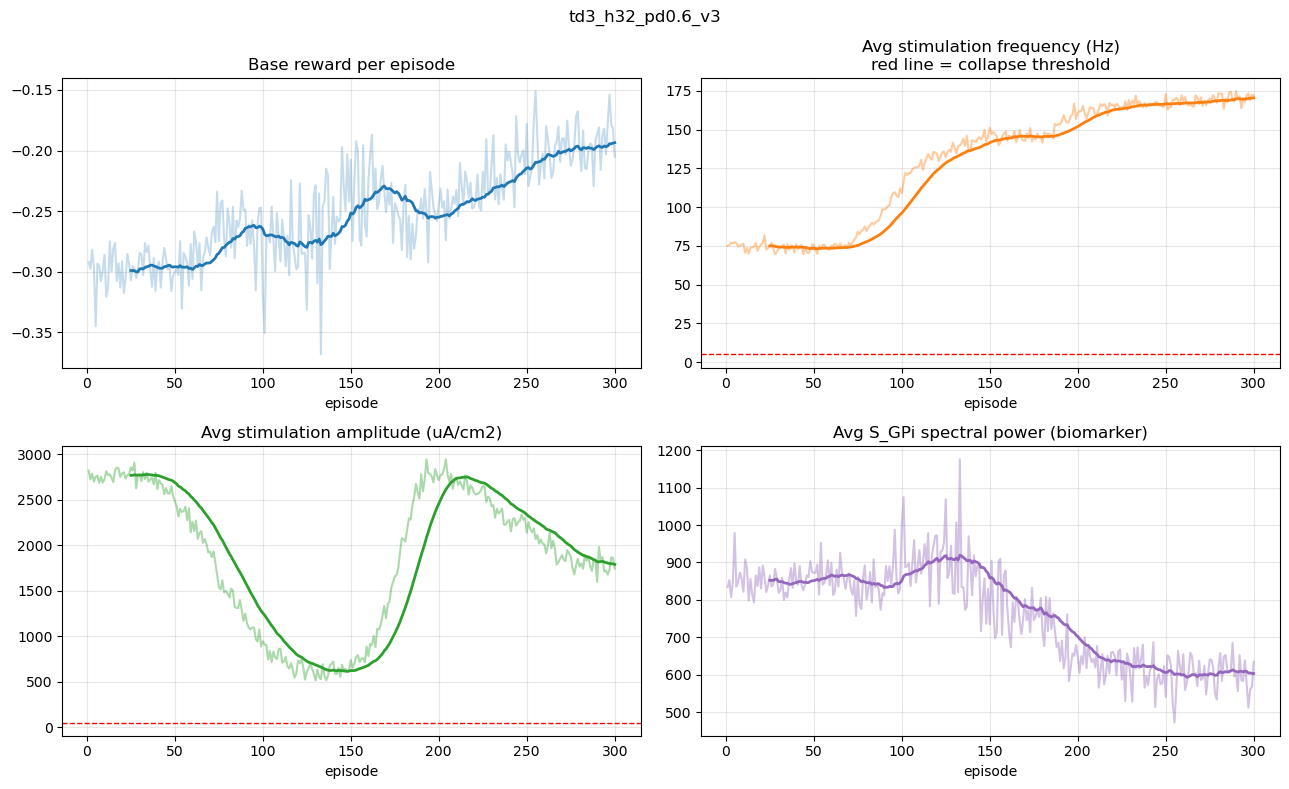

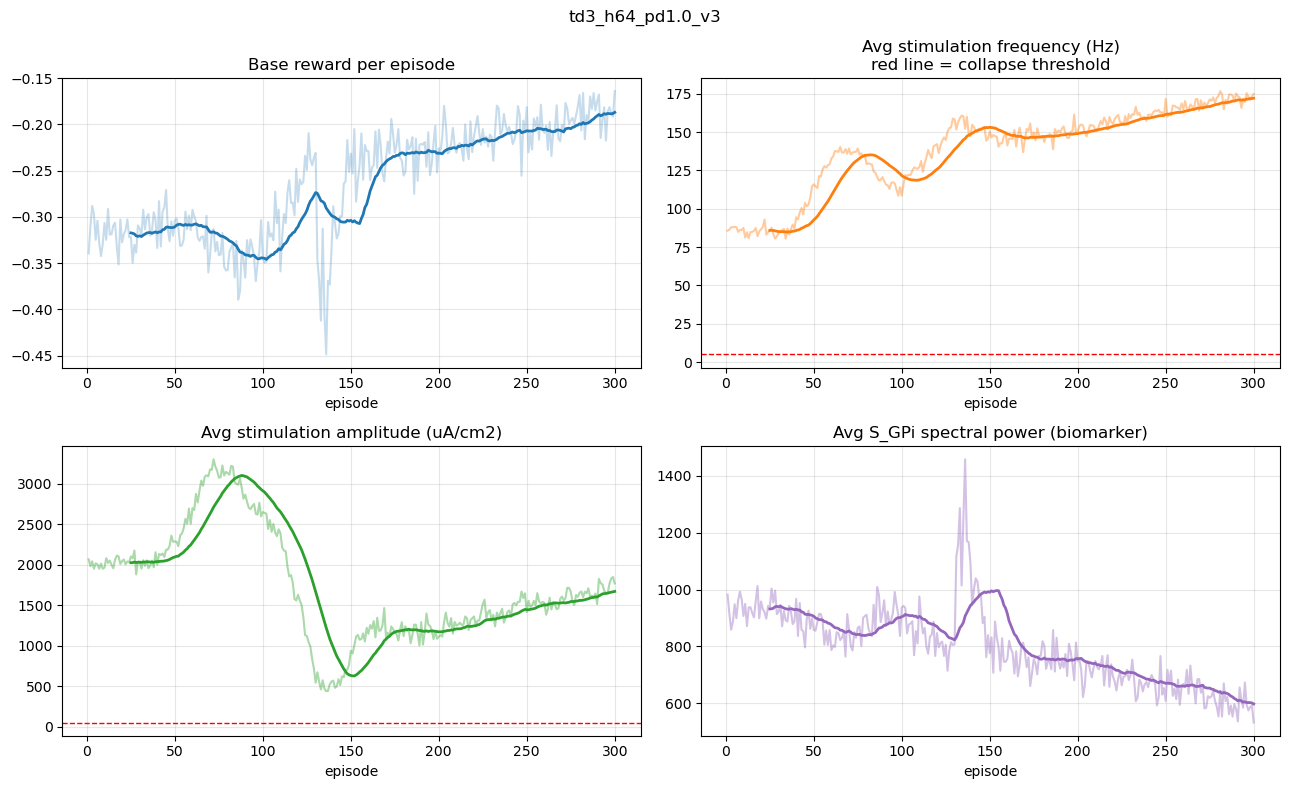

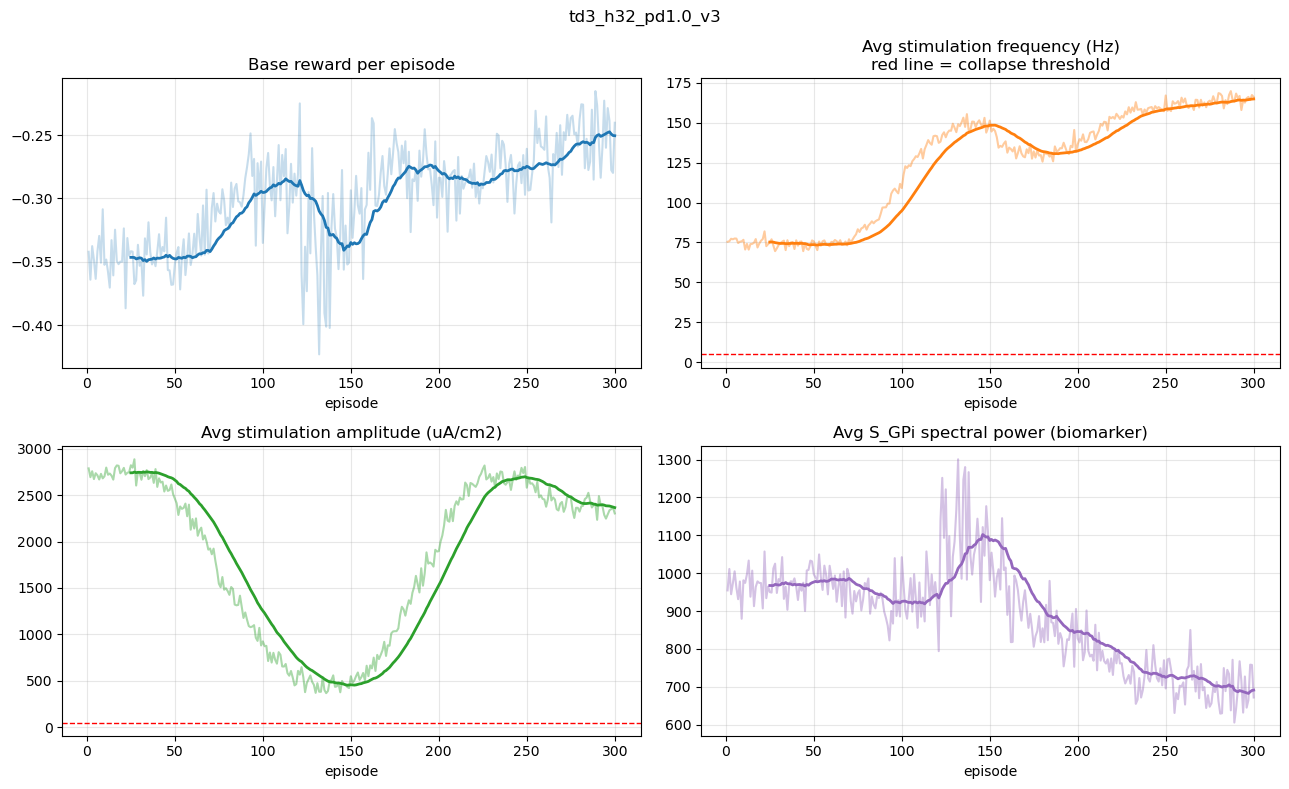

In [9]:
import json, time, traceback
from pathlib import Path

PD_VALUES = [0.3, 0.6, 1.0]
HIDDEN_DIMS = [64, 32]
N_EPISODES = 300

summary = {}
t_start = time.time()

for pd in PD_VALUES:
    for hidden in HIDDEN_DIMS:
        run_cfg = replace(cfg, pd_value=pd, hidden_dim=hidden, n_episodes=N_EPISODES)
        name = run_cfg.name()
        print(f"\n{'='*70}\n{name}  |  started {time.strftime('%H:%M:%S')}\n{'='*70}")
        entry = {"pd": pd, "hidden": hidden, "started": time.strftime("%Y-%m-%d %H:%M:%S")}
        try:
            menv.cfg = run_cfg
            ok, samples, _ = dbs_checks.live(menv, run_cfg, verbose=False)
            entry["env_checks_passed"] = bool(ok)
            if not ok:
                print(f"  !! env checks failed at pd={pd} — training anyway, treat with caution")

            t0 = time.time()
            agent, logger = train(run_cfg, menv, verbose=True)
            entry["train_minutes"] = round((time.time() - t0) / 60, 1)

            ev = evaluate(run_cfg, menv, agent, n_episodes=10)
            entry.update({
                "eval_reward": round(float(np.mean([r["reward"] for r in ev])), 4),
                "eval_freq": round(float(np.mean([r["freq"] for r in ev])), 1),
                "eval_amp": round(float(np.mean([r["amp"] for r in ev])), 0),
                "eval_sgis": round(float(np.mean([r["sgis"] for r in ev])), 0),
                "run_dir": str(logger.dir),
            })

            fixed = dbs_checks.baseline(menv, run_cfg, n_episodes=3)
            best = max((k for k in fixed if k[0] > 0), key=lambda k: fixed[k]["all"])
            entry["best_fixed"] = {"freq": best[0], "amp": best[1],
                                   "reward": round(fixed[best]["all"], 4),
                                   "sgis": round(fixed[best]["sgis"], 0)}

            dbs_plots.plot_training(logger.dir)
            entry["status"] = "ok"
            print(f"  done in {entry['train_minutes']} min | "
                  f"eval {entry['eval_reward']:+.4f} | sgis {entry['eval_sgis']:.0f}")
        except Exception as e:
            entry["status"] = "failed"
            entry["error"] = f"{type(e).__name__}: {e}"
            print(f"  !! FAILED: {type(e).__name__}: {e}")
            traceback.print_exc()

        summary[name] = entry
        Path("runs").mkdir(exist_ok=True)
        Path("runs/batch_summary.json").write_text(json.dumps(summary, indent=2))

print(f"\n{'='*70}")
print(f"batch finished in {(time.time()-t_start)/60:.1f} min")
print(f"{'name':<28} {'status':<8} {'eval':>9} {'sgis':>7} {'best fixed':>11}")
print("-" * 70)
for name, e in summary.items():
    bf = f"{e['best_fixed']['reward']:+.4f}" if "best_fixed" in e else "—"
    ev = f"{e['eval_reward']:+.4f}" if "eval_reward" in e else "—"
    sg = f"{e['eval_sgis']:.0f}" if "eval_sgis" in e else "—"
    print(f"{name:<28} {e['status']:<8} {ev:>9} {sg:>7} {bf:>11}")

## 8. Short run

30 episodes to confirm the loop survives.

In [10]:
import json
s = json.load(open("runs/batch_summary.json"))
print(f"{'run':<26} {'ok':<6} {'envchk':<7} {'eval':>9} {'sgis':>7} {'freq':>7} {'amp':>7} {'best fixed':>11} {'bf sgis':>8}")
print("-" * 96)
for name, e in s.items():
    bf = e.get("best_fixed", {})
    print(f"{name:<26} {e['status']:<6} {str(e.get('env_checks_passed','?')):<7} "
          f"{e.get('eval_reward','—'):>9} {e.get('eval_sgis','—'):>7} "
          f"{e.get('eval_freq','—'):>7} {e.get('eval_amp','—'):>7} "
          f"{bf.get('reward','—'):>11} {bf.get('sgis','—'):>8}")

run                        ok     envchk       eval    sgis    freq     amp  best fixed  bf sgis
------------------------------------------------------------------------------------------------
td3_h64_pd0.3_v3           ok     True      -0.2116   715.0   115.0  1264.0     -0.0863    363.0
td3_h32_pd0.3_v3           ok     True      -0.2157   730.0   118.5  1171.0     -0.0883    391.0
td3_h64_pd0.6_v3           ok     True       -0.151   662.0    92.5     1.0     -0.1029    438.0
td3_h32_pd0.6_v3           ok     True      -0.1883   600.0   172.3  1682.0     -0.0905    335.0
td3_h64_pd1.0_v3           ok     True      -0.1869   593.0   175.9  1700.0     -0.1043    419.0
td3_h32_pd1.0_v3           ok     True      -0.2456   687.0   165.0  2273.0     -0.0863    350.0


[td3_h64_pd0.4_v3_smoke] actor 4610 | critic 9346 | pd=0.4 | rms_max=1200.0 | start ep 0
  ep   10 | reward -0.2750 | freq   88.6 Hz | amp   1956 | buffer 140
  ep   20 | reward -0.2557 | freq   87.8 Hz | amp   2038 | buffer 280
  ep   30 | reward -0.2462 | freq   84.5 Hz | amp   2034 | buffer 420


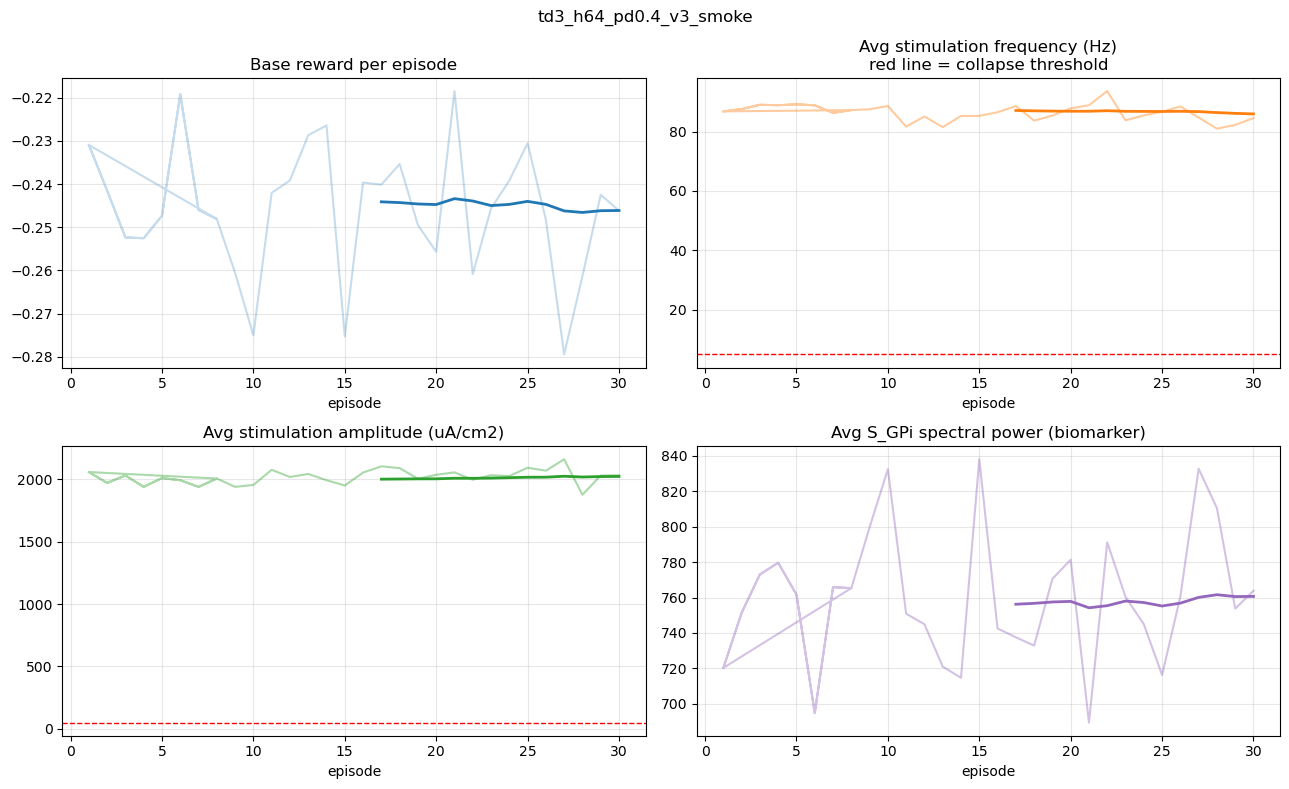

In [8]:
smoke_cfg = replace(cfg, n_episodes=30, checkpoint_every=10, tag="v3_smoke")
smoke_env = MatlabEnv(smoke_cfg, mat_path="bgn_vars.mat")
smoke_agent, smoke_logger = train(smoke_cfg, smoke_env, verbose=True)
smoke_env.close()
dbs_plots.plot_training(smoke_logger.dir);

## 9. Full run

First ~33 episodes are warmup with no learning. Checkpoints every 50 to `runs/<name>/`.

In [ ]:
agent, logger = train(cfg, menv, verbose=True)
print("\nrun directory:", logger.dir)

## 10. Evaluate

In [ ]:
eval_rows = evaluate(cfg, menv, agent, n_episodes=15)
print(f"avg reward: {np.mean([r['reward'] for r in eval_rows]):+.4f}")
print(f"avg freq:   {np.mean([r['freq'] for r in eval_rows]):.1f} Hz")
print(f"avg amp:    {np.mean([r['amp'] for r in eval_rows]):.0f} uA/cm2")
print(f"avg sgis:   {np.mean([r['sgis'] for r in eval_rows]):.0f}")

best_fixed = max((k for k in fixed if k[0] > 0), key=lambda k: fixed[k]["all"])
print(f"\nbest fixed: {best_fixed[0]}Hz/{best_fixed[1]} -> {fixed[best_fixed]['all']:+.4f}, "
      f"sgis {fixed[best_fixed]['sgis']:.0f}")

dbs_plots.plot_training(logger.dir)
dbs_plots.plot_eval(logger.dir, eval_rows);

## 11. Switch to 32

Change `hidden_dim` only. Everything else — seed, rms_max, episodes — stays identical,
which is what makes this a controlled comparison.

In [ ]:
menv.close()
cfg = replace(cfg, hidden_dim=32)
menv = MatlabEnv(cfg, mat_path="bgn_vars.mat")
print(cfg.name(), "| rms_max", cfg.rms_max, "| episodes", cfg.n_episodes)

In [ ]:
agent32, logger32 = train(cfg, menv, verbose=True)
eval32 = evaluate(cfg, menv, agent32, n_episodes=15)
print(f"\navg reward: {np.mean([r['reward'] for r in eval32]):+.4f}")
print(f"avg sgis:   {np.mean([r['sgis'] for r in eval32]):.0f}")

## 12. Compare

In [ ]:
import csv, statistics as st

def summarize(d, last=150):
    rows = list(csv.DictReader(open(f"runs/{d}/metrics.csv")))
    g = lambda k: [float(x[k]) for x in rows][-last:]
    return g("base_reward"), g("avg_freq"), g("avg_amp"), g("avg_sgis")

names = ["td3_h32_pd0.4_v3", "td3_h64_pd0.4_v3"]
res = {}
for d in names:
    r, f, a, s = summarize(d)
    res[d] = r
    print(f"{d}: reward {st.mean(r):+.4f} +/- {st.stdev(r):.4f} | "
          f"freq {st.mean(f):.1f} | amp {st.mean(a):.0f} | sgis {st.mean(s):.0f}")

r32, r64 = res[names[0]], res[names[1]]
pooled = ((st.stdev(r32) ** 2 + st.stdev(r64) ** 2) / 2) ** 0.5
print(f"\ngap (64-32) {st.mean(r64) - st.mean(r32):+.4f} = "
      f"{abs(st.mean(r64) - st.mean(r32)) / pooled:.2f} sd")

dbs_plots.compare_runs([f"runs/{n}" for n in names],
                       save_to="runs/compare_32_vs_64_v3.png");

## Shut down

In [ ]:
menv.close()
print("engine closed")

In [2]:
import helpers, dbs_t3p as t3p

backend = t3p.MatlabBackend(code_dir=".", parent_dir=".")
cfg = t3p.T3PConfig(pd_value=1.0, tmax=1000)

rows = t3p.sweep_all_arms(backend, cfg, helpers, repeats=5)

MATLAB cwd .
MATLAB path + matlab, matlab/gating
sweeping 31 arms at pd=1.0, 5 rep(s) each
 idx arm                    pb      r1      r2      r3    reward
--------------------------------------------------------------
   0 no DBS             176314   0.712   0.000   1.000   -0.3986
   1 55Hz/1000          148839   0.576   0.112   0.013   -0.4239
   2 55Hz/2000          159013   0.626   0.223   0.013   -0.4816
   3 55Hz/3000          151535   0.589   0.335   0.013   -0.4779
   4 55Hz/4000          176676   0.714   0.446   0.013   -0.5878
   5 55Hz/5000          143748   0.550   0.558   0.013   -0.4954
   6 80Hz/1000           98419   0.325   0.133   0.007   -0.2532
   7 80Hz/2000          101122   0.338   0.267   0.007   -0.2893
   8 80Hz/3000          117965   0.422   0.400   0.007   -0.3746
   9 80Hz/4000          111770   0.391   0.533   0.007   -0.3797
  10 80Hz/5000          116562   0.415   0.667   0.007   -0.4231
  11 105Hz/1000          65709   0.162   0.153   0.004   -0.1436
 

In [3]:
cfg = t3p.T3PConfig(pd_value=1.0, tmax=1000)
res, bandit = t3p.run_t3p(backend, cfg, helpers)

[t3p_pd1.0_K25_eps0.2] 31 arms | K=25 | eps 0.2->0.0 decay 0.025 | 75 rounds after warm-up
  warmup 10/31 | 0.4 min
  warmup 20/31 | 0.8 min
  warmup 30/31 | 1.1 min
  pruned 6 arms, 25 remain
  no-DBS arm KEPT
  round  41 | exploit 155Hz/1000 r=-0.1607 | best so far 155Hz/1000
  round  51 | exploit 155Hz/1000 r=-0.1386 | best so far 155Hz/1000
  round  61 | exploit 155Hz/1000 r=-0.0862 | best so far 155Hz/1000
  round  71 | exploit 155Hz/1000 r=-0.1389 | best so far 155Hz/1000
  round  81 | exploit 155Hz/1000 r=-0.0496 | best so far 155Hz/1000
  round  91 | exploit 155Hz/1000 r=-0.1054 | best so far 155Hz/1000
  round 101 | exploit 155Hz/1000 r=-0.0914 | best so far 155Hz/1000

converged to 155Hz/1000 (Q=-0.1182) in 4.1 min
  saved -> runs_t3p/t3p_pd1.0_K25_eps0.2_20260910-113912.json


In [4]:
results = []
for pd in [0.1, 0.4, 0.7, 1.0]:
    cfg = t3p.T3PConfig(pd_value=pd, tmax=1000, tag="v1")
    res, _ = t3p.run_t3p(backend, cfg, helpers)
    results.append(res)

t3p.compare_severities(results)

[t3p_pd0.1_K25_eps0.2_v1] 31 arms | K=25 | eps 0.2->0.0 decay 0.025 | 75 rounds after warm-up
  warmup 10/31 | 0.4 min
  warmup 20/31 | 0.8 min
  warmup 30/31 | 1.2 min
  pruned 6 arms, 25 remain
  no-DBS arm PRUNED
  round  41 | exploit 155Hz/1000 r=-0.1023 | best so far 155Hz/1000
  round  51 | exploit 155Hz/1000 r=-0.1242 | best so far 155Hz/1000
  round  61 | exploit 155Hz/1000 r=-0.2573 | best so far 155Hz/1000
  round  71 | exploit 155Hz/1000 r=-0.0875 | best so far 155Hz/1000
  round  81 | exploit 155Hz/1000 r=-0.1231 | best so far 155Hz/1000
  round  91 | exploit 155Hz/1000 r=-0.1006 | best so far 155Hz/1000
  round 101 | exploit 155Hz/1000 r=-0.0644 | best so far 155Hz/1000

converged to 155Hz/1000 (Q=-0.1011) in 4.5 min
  saved -> runs_t3p/t3p_pd0.1_K25_eps0.2_v1_20260910-114609.json
[t3p_pd0.4_K25_eps0.2_v1] 31 arms | K=25 | eps 0.2->0.0 decay 0.025 | 75 rounds after warm-up
  warmup 10/31 | 0.4 min
  warmup 20/31 | 0.9 min
  warmup 30/31 | 1.3 min
  pruned 6 arms, 25 remain

[{'pd': 0.1, 'freq': 155, 'amp': 1000, 'Q': -0.1010677210753607},
 {'pd': 0.4, 'freq': 155, 'amp': 1000, 'Q': -0.10915596784415424},
 {'pd': 0.7, 'freq': 105, 'amp': 1000, 'Q': -0.11243935009596481},
 {'pd': 1.0, 'freq': 155, 'amp': 1000, 'Q': -0.11719350637892495}]

In [5]:
import numpy as np
for pd in [0.0, 0.2, 0.5, 1.0]:
    cfg = t3p.T3PConfig(pd_value=pd, tmax=1000)
    pbs = [helpers.calculate_pb_absolute(backend.simulate(130, 0, cfg)[0]) for _ in range(3)]
    print(f"pd={pd}: untreated pb = {np.mean(pbs):>8.0f} (sd {np.std(pbs):>6.0f})")

pd=0.0: untreated pb =   175249 (sd   6535)
pd=0.2: untreated pb =   192731 (sd  19889)
pd=0.5: untreated pb =   197430 (sd  12430)
pd=1.0: untreated pb =   155672 (sd   2108)


In [6]:
import scipy.io
for pd in [0.0, 1.0]:
    cfg = t3p.T3PConfig(pd_value=pd, tmax=1000)
    backend.eng.bgn_init(float(pd), float(cfg.tmax), 12345, nargout=0)
    d = scipy.io.loadmat("bgn_vars.mat")
    print(f"requested pd={pd} -> stored pd={float(d['pd'].flatten()[0])}")

requested pd=0.0 -> stored pd=0.0
requested pd=1.0 -> stored pd=1.0


In [7]:
import numpy as np
for pd in [0.0, 1.0]:
    cfg = t3p.T3PConfig(pd_value=pd, tmax=1000)
    pbs = [helpers.calculate_pb_absolute(backend.simulate(130, 0, cfg)[0]) for _ in range(10)]
    print(f"pd={pd}: {np.mean(pbs):>8.0f} +/- {np.std(pbs)/np.sqrt(10):>6.0f} (n=10)")

pd=0.0:   157906 +/-   5816 (n=10)
pd=1.0:   166768 +/-   7385 (n=10)


In [8]:
import numpy as np
res = {}
for pd in [0.0, 1.0]:
    cfg = t3p.T3PConfig(pd_value=pd, tmax=1000)
    a, b = [], []
    for _ in range(6):
        vgi, _ = backend.simulate(130, 0, cfg)
        a.append(helpers.calculate_pb_absolute(vgi))
        b.append(helpers.calculate_pb(vgi))
    res[pd] = (np.mean(a), np.std(a), np.mean(b), np.std(b))

for name, i in [("calculate_pb_absolute", 0), ("calculate_pb", 2)]:
    h, p = res[0.0][i], res[1.0][i]
    sh, sp = res[0.0][i+1], res[1.0][i+1]
    print(f"{name:<22} healthy {h:>9.0f} +/- {sh:>7.0f} | "
          f"PD {p:>9.0f} +/- {sp:>7.0f} | ratio {p/h:.2f}")

calculate_pb_absolute  healthy    142084 +/-    9714 | PD    176823 +/-   16439 | ratio 1.24
calculate_pb           healthy    369808 +/-   10891 | PD   1047640 +/-   32828 | ratio 2.83


In [9]:
from pathlib import Path
needed = ["th_minf","th_hinf","th_pinf","th_rinf","th_tauh","th_taur",
          "stn_minf","stn_ninf","stn_hinf","stn_ainf","stn_binf","stn_rinf",
          "stn_cinf","stn_taun","stn_tauh","stn_taur","stn_tauc",
          "gpe_minf","gpe_ninf","gpe_hinf","gpe_ainf","gpe_sinf","gpe_rinf",
          "gpe_taun","gpe_tauh","Hinf"]
have = {p.stem for p in Path("gating").glob("*.m")}
missing = [f for f in needed if f not in have]
print(f"{len(have)} .m files in gating/")
print("missing:", missing or "none")

28 .m files in gating/
missing: none


In [2]:
import numpy as np
import helpers
import dbs_t3p as t3p

print("t3p version:", t3p.__version__)
assert t3p.__version__ == "3.1.0", "old dbs_t3p.py — replace the file"

backend = t3p.MatlabBackend(code_dir=".", parent_dir=".")

t3p version: 3.1.0
MATLAB cwd .
MATLAB path + ., gating


In [4]:
from pathlib import Path
root = Path.cwd()
backend.eng.addpath(str(root / "matlab"), nargout=0)
backend.eng.addpath(str(root / "gating"), nargout=0)
print(backend.eng.which("bgn_init"))
print(backend.eng.which("stn_ninf"))
cfg = t3p.T3PConfig(pd_value=1.0, tmax=1000)
rows = t3p.sweep_all_arms(backend, cfg, helpers, repeats=1)

/Users/willzellers/UNC/Research/Code/will-code/will-code-current/workspace/matlab/bgn_init.m
/Users/willzellers/UNC/Research/Code/will-code/will-code-current/workspace/gating/stn_ninf.m
sweeping 31 arms at pd=1.0, 1 rep(s) each
biomarker: calculate_pb / normalize_pb
 idx arm                    pb      r1      r2      r3    reward
--------------------------------------------------------------
   0 no DBS            1084469   0.965   0.000   1.000   -0.5756
   1 55Hz/1000          653146   0.542   0.112   0.013   -0.4007
   2 55Hz/2000          687815   0.576   0.223   0.013   -0.4468
   3 55Hz/3000          481583   0.374   0.335   0.013   -0.3275
   4 55Hz/4000          700705   0.589   0.446   0.013   -0.5002
   5 55Hz/5000          668460   0.557   0.558   0.013   -0.5004
   6 80Hz/1000          545599   0.437   0.133   0.007   -0.3318
   7 80Hz/2000          544399   0.436   0.267   0.007   -0.3576
   8 80Hz/3000          502326   0.394   0.400   0.007   -0.3554
   9 80Hz/4000      

In [5]:
results = []
for pd in [0.1, 0.4, 0.7, 1.0]:
    cfg = t3p.T3PConfig(pd_value=pd, tmax=1000, tag="v2")
    res, _ = t3p.run_t3p(backend, cfg, helpers)
    results.append(res)

t3p.compare_severities(results)

[t3p_pd0.1_K25_eps0.2_v2] 31 arms | K=25 | eps 0.2->0.0 decay 0.025 | 75 rounds after warm-up
  biomarker: calculate_pb / normalize_pb
  warmup 10/31 | 0.4 min
  warmup 20/31 | 0.8 min
  warmup 30/31 | 1.2 min
  pruned 6 arms, 25 remain
  no-DBS arm KEPT
  round  41 | exploit 155Hz/1000 r=-0.0263 | best so far 155Hz/1000
  round  51 | exploit 155Hz/1000 r=-0.0257 | best so far 155Hz/1000
  round  61 | exploit 155Hz/1000 r=-0.0242 | best so far 155Hz/1000
  round  71 | exploit 155Hz/1000 r=-0.0217 | best so far 155Hz/1000
  round  81 | exploit 155Hz/1000 r=-0.0339 | best so far 155Hz/1000
  round  91 | exploit 155Hz/1000 r=-0.0388 | best so far 155Hz/1000
  round 101 | exploit 155Hz/1000 r=-0.0308 | best so far 155Hz/1000

converged to 155Hz/1000 (Q=-0.0265) in 4.1 min
  saved -> runs_t3p/t3p_pd0.1_K25_eps0.2_v2_20260910-123747.json
[t3p_pd0.4_K25_eps0.2_v2] 31 arms | K=25 | eps 0.2->0.0 decay 0.025 | 75 rounds after warm-up
  biomarker: calculate_pb / normalize_pb
  warmup 10/31 | 0.4 

[{'pd': 0.1, 'freq': 155, 'amp': 1000, 'Q': -0.026497227402673216},
 {'pd': 0.4, 'freq': 180, 'amp': 1000, 'Q': -0.036180381780987036},
 {'pd': 0.7, 'freq': 180, 'amp': 1000, 'Q': -0.04967538629934335},
 {'pd': 1.0, 'freq': 180, 'amp': 1000, 'Q': -0.039408131789780795}]

In [6]:
results = []
for pd in [0.1, 0.4, 0.7, 1.0]:
    for seed in [1, 2, 3]:
        cfg = t3p.T3PConfig(pd_value=pd, tmax=1000, seed=seed, tag=f"s{seed}")
        res, _ = t3p.run_t3p(backend, cfg, helpers, verbose=False)
        results.append(res)
        print(f"pd={pd} seed={seed}: {res['best_freq']}Hz/{res['best_curr']} Q={res['best_Q']:+.4f}")

pd=0.1 seed=1: 155Hz/1000 Q=-0.0270
pd=0.1 seed=2: 155Hz/1000 Q=-0.0262
pd=0.1 seed=3: 180Hz/1000 Q=-0.0272
pd=0.4 seed=1: 155Hz/1000 Q=-0.0440
pd=0.4 seed=2: 180Hz/1000 Q=-0.0376
pd=0.4 seed=3: 180Hz/1000 Q=-0.0363
pd=0.7 seed=1: 130Hz/1000 Q=-0.0613
pd=0.7 seed=2: 180Hz/1000 Q=-0.0504
pd=0.7 seed=3: 180Hz/1000 Q=-0.0505
pd=1.0 seed=1: 180Hz/1000 Q=-0.0397
pd=1.0 seed=2: 180Hz/1000 Q=-0.0394
pd=1.0 seed=3: 180Hz/1000 Q=-0.0404


In [7]:
t3p.CURR_VALUES = [0, 100, 250, 500, 750, 1000, 2000, 3500, 5000]
t3p.ARMS = t3p.build_arms()
cfg = t3p.T3PConfig(pd_value=0.1, tmax=1000, n_arms=len(t3p.ARMS))
rows = t3p.sweep_all_arms(backend, cfg, helpers, repeats=3)

sweeping 49 arms at pd=0.1, 3 rep(s) each
biomarker: calculate_pb / normalize_pb
 idx arm                    pb      r1      r2      r3    reward
--------------------------------------------------------------
   0 no DBS             453891   0.347   0.000   1.000   -0.1429
   1 55Hz/100           483719   0.376   0.011   0.013   -0.2643
   2 55Hz/250           537327   0.429   0.028   0.013   -0.3044
   3 55Hz/500           261501   0.158   0.056   0.013   -0.1207
   4 55Hz/750           249088   0.146   0.084   0.013   -0.1178
   5 55Hz/1000          234575   0.132   0.112   0.013   -0.1134
   6 55Hz/2000          235155   0.133   0.223   0.013   -0.1361
   7 55Hz/3500          245439   0.143   0.390   0.013   -0.1766
   8 55Hz/5000          230639   0.128   0.558   0.013   -0.1999
   9 80Hz/100           441879   0.335   0.013   0.007   -0.2366
  10 80Hz/250           541804   0.433   0.033   0.007   -0.3092
  11 80Hz/500           200771   0.099   0.067   0.007   -0.0818
  12 80Hz/7

In [8]:
import json
from pathlib import Path
for p in sorted(Path("runs_t3p").glob("*_s*.json")):
    r = json.loads(p.read_text())
    print(f"pd={r['config']['pd_value']} seed={r['config']['seed']}: "
          f"no-DBS {'KEPT' if 0 in r['active'] else 'PRUNED'}")

pd=0.1 seed=1: no-DBS KEPT
pd=0.1 seed=2: no-DBS PRUNED
pd=0.1 seed=3: no-DBS PRUNED
pd=0.4 seed=1: no-DBS PRUNED
pd=0.4 seed=2: no-DBS PRUNED
pd=0.4 seed=3: no-DBS PRUNED
pd=0.7 seed=1: no-DBS PRUNED
pd=0.7 seed=2: no-DBS PRUNED
pd=0.7 seed=3: no-DBS PRUNED
pd=1.0 seed=1: no-DBS PRUNED
pd=1.0 seed=2: no-DBS PRUNED
pd=1.0 seed=3: no-DBS PRUNED


In [9]:
cfg = t3p.T3PConfig(pd_value=1.0, tmax=1000, n_arms=len(t3p.ARMS))
rows_severe = t3p.sweep_all_arms(backend, cfg, helpers, repeats=3)

sweeping 49 arms at pd=1.0, 3 rep(s) each
biomarker: calculate_pb / normalize_pb
 idx arm                    pb      r1      r2      r3    reward
--------------------------------------------------------------
   0 no DBS            1113867   0.994   0.000   1.000   -0.5958
   1 55Hz/100          1111306   0.991   0.011   0.013   -0.6950
   2 55Hz/250          1085241   0.966   0.028   0.013   -0.6805
   3 55Hz/500           650665   0.540   0.056   0.013   -0.3878
   4 55Hz/750           696218   0.585   0.084   0.013   -0.4246
   5 55Hz/1000          622541   0.512   0.112   0.013   -0.3796
   6 55Hz/2000          659712   0.549   0.223   0.013   -0.4275
   7 55Hz/3500          600774   0.491   0.390   0.013   -0.4205
   8 55Hz/5000          644698   0.534   0.558   0.013   -0.4841
   9 80Hz/100          1078649   0.959   0.013   0.007   -0.6736
  10 80Hz/250          1026462   0.908   0.033   0.007   -0.6418
  11 80Hz/500           508298   0.400   0.067   0.007   -0.2928
  12 80Hz/7

In [10]:
 import numpy as np
probe = [(180, 500), (180, 750), (180, 1000)]
for pd in (0.1, 1.0):
    cfg = t3p.T3PConfig(pd_value=pd, tmax=1000)
    print(f"\npd={pd}")
    for f, a in probe:
        rs = [t3p.compute_reward(*backend.simulate(f, a, cfg), f, a, cfg, helpers)["reward"]
              for _ in range(10)]
        print(f"  {f}Hz/{a:<5} {np.mean(rs):+.4f} +/- {np.std(rs)/np.sqrt(10):.4f}")


pd=0.1
  180Hz/500   -0.0089 +/- 0.0033
  180Hz/750   -0.0156 +/- 0.0027
  180Hz/1000  -0.0286 +/- 0.0031

pd=1.0
  180Hz/500   -0.0206 +/- 0.0038
  180Hz/750   -0.0256 +/- 0.0031
  180Hz/1000  -0.0433 +/- 0.0029


In [11]:
import numpy as np
for pd in (0.1, 1.0):
    cfg = t3p.T3PConfig(pd_value=pd, tmax=1000)
    print(f"\npd={pd}")
    for a in (250, 300, 350, 400, 450, 500):
        rs = [t3p.compute_reward(*backend.simulate(180, a, cfg), 180, a, cfg, helpers)["reward"]
              for _ in range(10)]
        print(f"  180Hz/{a:<4} {np.mean(rs):+.4f} +/- {np.std(rs)/np.sqrt(10):.4f}")


pd=0.1
  180Hz/250  -0.3292 +/- 0.0058
  180Hz/300  -0.1020 +/- 0.0035
  180Hz/350  -0.0204 +/- 0.0013
  180Hz/400  -0.0125 +/- 0.0019
  180Hz/450  -0.0018 +/- 0.0034
  180Hz/500  -0.0023 +/- 0.0016

pd=1.0
  180Hz/250  -0.6428 +/- 0.0070
  180Hz/300  -0.3998 +/- 0.0096
  180Hz/350  -0.0574 +/- 0.0049
  180Hz/400  -0.0397 +/- 0.0034
  180Hz/450  -0.0276 +/- 0.0052
  180Hz/500  -0.0196 +/- 0.0039


In [12]:
import numpy as np
curves = {}
for pd in (0.1, 0.4, 0.7, 1.0):
    cfg = t3p.T3PConfig(pd_value=pd, tmax=1000)
    row = []
    for a in (250, 300, 350, 400, 450, 500):
        rs = [t3p.compute_reward(*backend.simulate(180, a, cfg), 180, a, cfg, helpers)["reward"]
              for _ in range(10)]
        row.append((a, float(np.mean(rs)), float(np.std(rs)/np.sqrt(10))))
    curves[pd] = row
    print(f"pd={pd}: " + "  ".join(f"{a}:{m:+.4f}" for a, m, _ in row))

def crossing(row, floor):
    for i in range(1, len(row)):
        if row[i-1][1] < floor <= row[i][1]:
            f = (floor - row[i-1][1]) / (row[i][1] - row[i-1][1])
            return row[i-1][0] + f * (row[i][0] - row[i-1][0])
    return None

print(f"\n{'floor':>8}" + "".join(f"{pd:>10}" for pd in curves))
for floor in (-0.05, -0.04, -0.03):
    line = f"{floor:>8.2f}"
    for pd in curves:
        c = crossing(curves[pd], floor)
        line += f"{c:>9.0f}u" if c else f"{'—':>10}"
    print(line)

pd=0.1: 250:-0.3236  300:-0.1004  350:-0.0153  400:-0.0123  450:-0.0015  500:-0.0048
pd=0.4: 250:-0.4995  300:-0.1775  350:-0.0276  400:-0.0309  450:-0.0196  500:-0.0163
pd=0.7: 250:-0.6072  300:-0.2379  350:-0.0426  400:-0.0464  450:-0.0268  500:-0.0292
pd=1.0: 250:-0.6534  300:-0.4277  350:-0.0444  400:-0.0308  450:-0.0300  500:-0.0231

   floor       0.1       0.4       0.7       1.0
   -0.05      330u      343u      348u      349u
   -0.04      335u      346u      416u      366u
   -0.03      341u      349u      442u      448u


In [13]:
for pd in (0.1, 1.0):
    cfg = t3p.T3PConfig(pd_value=pd, tmax=1000)
    rs0 = [t3p.compute_reward(*backend.simulate(130, 0, cfg), 130, 0, cfg, helpers)["reward"]
           for _ in range(5)]
    print(f"\npd={pd} | no DBS {np.mean(rs0):+.4f}")
    for a in (50, 100, 150, 200, 250):
        rs = [t3p.compute_reward(*backend.simulate(180, a, cfg), 180, a, cfg, helpers)["reward"]
              for _ in range(5)]
        flag = " worse than no DBS" if np.mean(rs) < np.mean(rs0) else ""
        print(f"  180Hz/{a:<4} {np.mean(rs):+.4f}{flag}")


pd=0.1 | no DBS -0.1404
  180Hz/50   -0.2421 worse than no DBS
  180Hz/100  -0.2451 worse than no DBS
  180Hz/150  -0.2532 worse than no DBS
  180Hz/200  -0.2433 worse than no DBS
  180Hz/250  -0.3221 worse than no DBS

pd=1.0 | no DBS -0.5786
  180Hz/50   -0.6435 worse than no DBS
  180Hz/100  -0.6495 worse than no DBS
  180Hz/150  -0.6352 worse than no DBS
  180Hz/200  -0.6256 worse than no DBS
  180Hz/250  -0.6450 worse than no DBS


In [14]:
import numpy as np

AMPS = [250, 300, 350, 400, 450, 500]
PDS = [0.1, 0.4, 0.7, 1.0]
N = 20

curves = {}
for pd in PDS:
    cfg = t3p.T3PConfig(pd_value=pd, tmax=1000)
    row = []
    for a in AMPS:
        rs = [t3p.compute_reward(*backend.simulate(180, a, cfg), 180, a, cfg, helpers)["reward"]
              for _ in range(N)]
        row.append((a, float(np.mean(rs)), float(np.std(rs, ddof=1) / np.sqrt(N))))
    curves[pd] = row
    print(f"pd={pd}: " + "  ".join(f"{a}:{m:+.4f}±{s:.4f}" for a, m, s in row))

print(f"\n{'amp':>5} " + "".join(f"{f'pd={p}':>18}" for p in PDS) + "   monotonic?")
for i, a in enumerate(AMPS):
    vals = [curves[p][i][1] for p in PDS]
    ses = [curves[p][i][2] for p in PDS]
    ok = all(vals[j] >= vals[j+1] for j in range(len(vals)-1))
    line = f"{a:>5} " + "".join(f"{v:>11.4f}±{s:.4f}" for v, s in zip(vals, ses))
    print(line + ("   yes" if ok else "   NO"))

print("\npd=0.7 vs pd=1.0 head to head:")
for i, a in enumerate(AMPS):
    m7, s7 = curves[0.7][i][1], curves[0.7][i][2]
    m10, s10 = curves[1.0][i][1], curves[1.0][i][2]
    d = m7 - m10
    print(f"  {a:>4}u  diff {d:+.4f}  ({abs(d)/np.hypot(s7, s10):.1f} sigma)"
          + ("  <- inverted" if d < 0 else ""))

pd=0.1: 250:-0.3153±0.0047  300:-0.1045±0.0038  350:-0.0187±0.0012  400:-0.0129±0.0017  450:-0.0059±0.0018  500:-0.0102±0.0021
pd=0.4: 250:-0.5047±0.0059  300:-0.1775±0.0031  350:-0.0275±0.0016  400:-0.0218±0.0016  450:-0.0124±0.0022  500:-0.0142±0.0017
pd=0.7: 250:-0.6028±0.0063  300:-0.2281±0.0041  350:-0.0434±0.0023  400:-0.0376±0.0023  450:-0.0285±0.0018  500:-0.0273±0.0020
pd=1.0: 250:-0.6231±0.0068  300:-0.4240±0.0099  350:-0.0431±0.0025  400:-0.0376±0.0026  450:-0.0292±0.0020  500:-0.0205±0.0024

  amp             pd=0.1            pd=0.4            pd=0.7            pd=1.0   monotonic?
  250     -0.3153±0.0047    -0.5047±0.0059    -0.6028±0.0063    -0.6231±0.0068   yes
  300     -0.1045±0.0038    -0.1775±0.0031    -0.2281±0.0041    -0.4240±0.0099   yes
  350     -0.0187±0.0012    -0.0275±0.0016    -0.0434±0.0023    -0.0431±0.0025   NO
  400     -0.0129±0.0017    -0.0218±0.0016    -0.0376±0.0023    -0.0376±0.0026   NO
  450     -0.0059±0.0018    -0.0124±0.0022    -0.0285±0.0018 

In [15]:
print(f"\n{'pd':>6} {'reward @180Hz/450':>22} {'pb':>12}")
for pd in [0.5, 0.6, 0.65, 0.7, 0.75, 0.8, 0.9]:
    cfg = t3p.T3PConfig(pd_value=pd, tmax=1000)
    recs = [t3p.compute_reward(*backend.simulate(180, 450, cfg), 180, 450, cfg, helpers)
            for _ in range(15)]
    r = [x["reward"] for x in recs]
    pb = [x["pb"] for x in recs]
    print(f"{pd:>6} {np.mean(r):>14.4f}±{np.std(r, ddof=1)/np.sqrt(15):.4f} "
          f"{np.mean(pb):>12.0f}")


    pd      reward @180Hz/450           pb
   0.5        -0.0195±0.0022       102245
   0.6        -0.0269±0.0022       112941
  0.65        -0.0233±0.0016       107665
   0.7        -0.0314±0.0026       119466
  0.75        -0.0274±0.0028       113753
   0.8        -0.0370±0.0029       127716
   0.9        -0.0313±0.0024       119432


In [16]:
import numpy as np

AMPS = [250, 300, 350, 450]
PDS = [0.1, 1.0]
FREQS = [130, 155, 180]
N = 15

out = {}
for f in FREQS:
    print(f"\n=== {f} Hz ===")
    for pd in PDS:
        cfg = t3p.T3PConfig(pd_value=pd, tmax=1000)
        row = []
        for a in AMPS:
            rs = [t3p.compute_reward(*backend.simulate(f, a, cfg), f, a, cfg, helpers)["reward"]
                  for _ in range(N)]
            row.append((a, float(np.mean(rs)), float(np.std(rs, ddof=1)/np.sqrt(N))))
        out[(f, pd)] = row
        print(f"  pd={pd}: " + "  ".join(f"{a}:{m:+.4f}±{s:.4f}" for a, m, s in row))

print(f"\n{'freq':>6} {'amp':>6} {'mild':>10} {'severe':>10} {'gap':>9} {'sigma':>7}")
print("-" * 54)
for f in FREQS:
    for i, a in enumerate(AMPS):
        m, sm = out[(f, 0.1)][i][1], out[(f, 0.1)][i][2]
        s, ss = out[(f, 1.0)][i][1], out[(f, 1.0)][i][2]
        print(f"{f:>6} {a:>6} {m:>10.4f} {s:>10.4f} {m-s:>+9.4f} "
              f"{abs(m-s)/np.hypot(sm, ss):>7.1f}")


=== 130 Hz ===
  pd=0.1: 250:-0.3154±0.0055  300:-0.1665±0.0029  350:-0.0328±0.0013  450:-0.0366±0.0016
  pd=1.0: 250:-0.6329±0.0078  300:-0.4594±0.0083  350:-0.0461±0.0026  450:-0.0452±0.0015

=== 155 Hz ===
  pd=0.1: 250:-0.3149±0.0060  300:-0.1549±0.0027  350:-0.0195±0.0017  450:-0.0078±0.0016
  pd=1.0: 250:-0.6358±0.0063  300:-0.4278±0.0062  350:-0.0735±0.0025  450:-0.0646±0.0018

=== 180 Hz ===
  pd=0.1: 250:-0.3099±0.0062  300:-0.1144±0.0040  350:-0.0205±0.0011  450:-0.0048±0.0024
  pd=1.0: 250:-0.6488±0.0077  300:-0.4216±0.0103  350:-0.0431±0.0044  450:-0.0250±0.0027

  freq    amp       mild     severe       gap   sigma
------------------------------------------------------
   130    250    -0.3154    -0.6329   +0.3175    33.4
   130    300    -0.1665    -0.4594   +0.2929    33.4
   130    350    -0.0328    -0.0461   +0.0132     4.5
   130    450    -0.0366    -0.0452   +0.0086     4.0
   155    250    -0.3149    -0.6358   +0.3208    37.0
   155    300    -0.1549    -0.4278   

In [17]:
import numpy as np

for pd in (0.1, 1.0):
    cfg = t3p.T3PConfig(pd_value=pd, tmax=1000)
    base = [t3p.compute_reward(*backend.simulate(130, 0, cfg), 130, 0, cfg, helpers)["pb"]
            for _ in range(15)]
    b, bse = np.mean(base), np.std(base, ddof=1)/np.sqrt(15)
    print(f"\npd={pd} | no DBS pb = {b:,.0f} +/- {bse:,.0f}")
    print(f"{'amp':>6} {'pb':>12} {'vs no-DBS':>12} {'sigma':>7}")
    for a in (150, 200, 250, 275, 300, 325, 350):
        v = [t3p.compute_reward(*backend.simulate(180, a, cfg), 180, a, cfg, helpers)["pb"]
             for _ in range(15)]
        m, se = np.mean(v), np.std(v, ddof=1)/np.sqrt(15)
        sig = (m - b) / np.hypot(se, bse)
        tag = "  HARMFUL" if sig > 2 else ("  helps" if sig < -2 else "  same")
        print(f"{a:>6} {m:>12,.0f} {m-b:>+12,.0f} {sig:>7.1f}{tag}")


pd=0.1 | no DBS pb = 453,262 +/- 7,979
   amp           pb    vs no-DBS   sigma
   150      451,345       -1,917    -0.2  same
   200      455,115       +1,853     0.2  same
   250      558,140     +104,877    11.1  HARMFUL
   275      526,106      +72,843     7.9  HARMFUL
   300      229,996     -223,266   -23.8  helps
   325      112,410     -340,852   -39.8  helps
   350      113,992     -339,270   -41.4  helps

pd=1.0 | no DBS pb = 1,061,368 +/- 12,814
   amp           pb    vs no-DBS   sigma
   150    1,020,788      -40,580    -2.2  helps
   200      985,622      -75,745    -3.4  helps
   250    1,022,869      -38,499    -2.5  helps
   275    1,028,416      -32,952    -1.9  same
   300      679,754     -381,614   -20.7  helps
   325      264,522     -796,846   -44.9  helps
   350      141,542     -919,826   -68.0  helps


In [18]:
print(f"\n{'seed':>6} {'mild@450':>12} {'severe@450':>12} {'gap':>9}")
for seed in (11, 22, 33):
    out = {}
    for pd in (0.1, 1.0):
        cfg = t3p.T3PConfig(pd_value=pd, tmax=1000, seed=seed)
        v = [t3p.compute_reward(*backend.simulate(155, 450, cfg), 155, 450, cfg, helpers)["reward"]
             for _ in range(12)]
        out[pd] = np.mean(v)
    print(f"{seed:>6} {out[0.1]:>12.4f} {out[1.0]:>12.4f} {out[0.1]-out[1.0]:>+9.4f}")


  seed     mild@450   severe@450       gap
    11      -0.0076      -0.0665   +0.0588
    22      -0.0069      -0.0614   +0.0545
    33      -0.0036      -0.0609   +0.0573
